DSCI 552 Homework 5

Name: Brynn Dafoe GitHub Username: brynndafoe02 USD ID: 3109-6692-10

In [1]:
from imblearn.under_sampling import RandomUnderSampler
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import re

import seaborn as sns

from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.metrics import RocCurveDisplay, roc_auc_score, accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree

from skmultilearn.problem_transform import LabelPowerset

import statsmodels.api as sm
import statsmodels.formula.api as smf

Question 1 -> diagnosis.data + diagnosis.names
Question 1.b
- Build a decision tree on the whole data set and plot it
- - This data set is a multi-label data set
  - Sk-Learn seems to support building multi-label decision trees
  - Alternatively, you can use the label powerset method to convert it to a multiclass data set
  - Also, you can use the binary relevance method and build one decision tree for each label
  - It seems that the label powerset approach is more relevent here

In [2]:
# -- Attribute lines:
# For example, '35,9 no no yes yes yes yes no'
# Where:
# '35,9' Temperature of patient
# 'no' Occurrence of nausea
# 'no' Lumbar pain
# 'yes' Urine pushing (continuous need for urination)
# 'yes' Micturition pains
# 'yes' Burning of urethra, itch, swelling of urethra outlet
# 'yes' decision: Inflammation of urinary bladder
# 'no' decision: Nephritis of renal pelvis origin 

# Attribute Information:

# a1 Temperature of patient { 35C-42C }
# a2 Occurrence of nausea { yes, no }
# a3 Lumbar pain { yes, no }
# a4 Urine pushing (continuous need for urination) { yes, no }
# a5 Micturition pains { yes, no }
# a6 Burning of urethra, itch, swelling of urethra outlet { yes, no }
# d1 decision: Inflammation of urinary bladder { yes, no }
# d2 decision: Nephritis of renal pelvis origin { yes, no } 

# ^^^ Inflam and Neph are being predicted on / = Y
# ^^^ T, N, LP, UP, MP, B = X

# "../data/CCPP/Folds5x2_pp.xlsx"

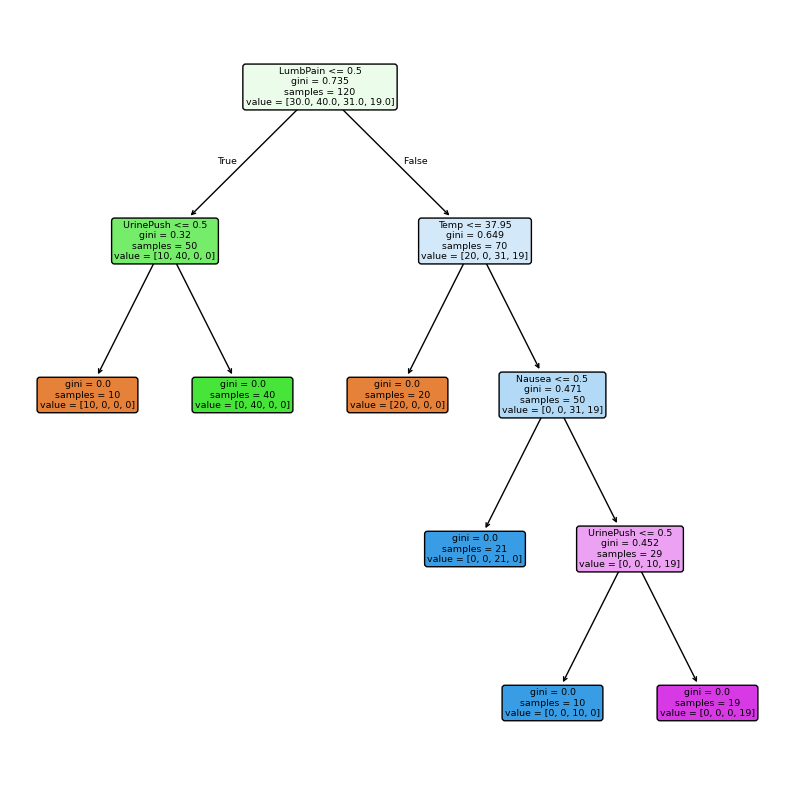

In [3]:
d_column_names = ["Temp", "Nausea", "LumbPain", "UrinePush", 
                  "MictPains", "Burning", "Inflam", "Neph"] # 8 columns

d_df = pd.read_csv("../data/diagnosis.data", header=None, names=d_column_names, decimal=',', sep=r'\s+', encoding='utf-16')

d_df = d_df.replace({"yes": 1, "no": 0})

# pd.set_option('display.max_rows', None)
# print(d_df)

d_X = d_df[["Temp", "Nausea", "LumbPain", "UrinePush", "MictPains", "Burning"]].astype(float).values
d_Y = d_df[["Inflam", "Neph"]].astype(float).values # forcing to be numbers because it was still reading as objects at first

clf = LabelPowerset(classifier=DecisionTreeClassifier(random_state=42))
clf.fit(d_X, d_Y)

plt.figure(figsize=(10, 10))
plot_tree(clf.classifier, feature_names=["Temp", "Nausea", "LumbPain", "UrinePush", "MictPains", "Burning"], filled=True, rounded=True)
plt.show()

    

Question 1.c
- Convert the decision rules into a set of IF-THEN rules
- - Using code from kdnuggets

In [4]:
def tree_to_pseudo(tree, feature_names):
    left = tree.tree_.children_left
    right = tree.tree_.children_right
    threshold = tree.tree_.threshold
    features = [feature_names[i] for i in tree.tree_.feature]
    value = tree.tree_.value

    def recurse(left, right, threshold, features, node, depth=0):
        indent = "  " * depth
        if threshold[node] != -2:
            print(indent,"if ( " + features[node] + " <= " + str(threshold[node]) + " ) {")
            if left[node] != -1:
                recurse(left, right, threshold, features, left[node], depth+1)
                print(indent,"} else {")
                if right[node] != -1:
                    recurse(left, right, threshold, features, right[node], depth+1)
                print(indent,"}")
        else:
            print(indent,"return " + str(value[node]))

    recurse(left, right, threshold, features, 0)
               

In [5]:
feature_names = ["Temp", "Nausea", "LumbPain", "UrinePush", "MictPains", "Burning"]
tree_to_pseudo(clf.classifier, feature_names)

 if ( LumbPain <= 0.5 ) {
   if ( UrinePush <= 0.5 ) {
     return [[1. 0. 0. 0.]]
   } else {
     return [[0. 1. 0. 0.]]
   }
 } else {
   if ( Temp <= 37.95000076293945 ) {
     return [[1. 0. 0. 0.]]
   } else {
     if ( Nausea <= 0.5 ) {
       return [[0. 0. 1. 0.]]
     } else {
       if ( UrinePush <= 0.5 ) {
         return [[0. 0. 1. 0.]]
       } else {
         return [[0. 0. 0. 1.]]
       }
     }
   }
 }


In [6]:
# ^^^ what the printed returns mean
print(clf.unique_combinations_)
# no labels, label 0 (Inflam), label 1 (Neph), both labels
# 1000 -> no labels -> Neither
# 0100 -> label 0 -> Inflammation
# 0010 -> label 1 -> Nephritis
# 0001 -> both labels -> Inflammation + Nephritis

{'': 0, '0': 1, '1': 2, '0,1': 3}


Question 1.d
- Use cost-complexity pruning to find a minimal decision tree and a set of decision rules with high interpretability

In [7]:
# d_X, d_Y
# doing manual over GridSearch because GridSearchCV gave me 100% test accuracy,
    # but the tree was not pruned any further than the one above because the one
    # above achieves 100% accuracy.
    # Going to pick a larger alpha that still has a good accuracy
        # in order to get a smaller tree 

d_X_train, d_X_test, d_Y_train, d_Y_test = train_test_split(d_X, d_Y, test_size=0.2, random_state=42)

clf_pruning = DecisionTreeClassifier(random_state=42)
clf_pruning.fit(d_X_train, d_Y_train)

path = clf_pruning.cost_complexity_pruning_path(d_X_train, d_Y_train)
ccp_alphas = path.ccp_alphas

# print(ccp_alphas) # -> [0.         0.05081301 0.08034677 0.10992908 0.20267279]

for alpha in ccp_alphas: # seeing test acc + depth to pick a tree that is pruned but still has good test acc
    diff_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    diff_tree.fit(d_X_train, d_Y_train)
    test_acc = diff_tree.score(d_X_test, d_Y_test)
    tree_depth = diff_tree.get_depth()

    print(f"Alpha Used: {alpha}")
    print(f"Test Accuracy: {test_acc}")
    print(f"Tree Depth: {tree_depth}\n")



Alpha Used: 0.0
Test Accuracy: 1.0
Tree Depth: 4

Alpha Used: 0.0508130081300813
Test Accuracy: 0.875
Tree Depth: 2

Alpha Used: 0.08034677285548367
Test Accuracy: 0.7916666666666666
Tree Depth: 2

Alpha Used: 0.1099290780141844
Test Accuracy: 0.625
Tree Depth: 1

Alpha Used: 0.20267278564794716
Test Accuracy: 0.25
Tree Depth: 0



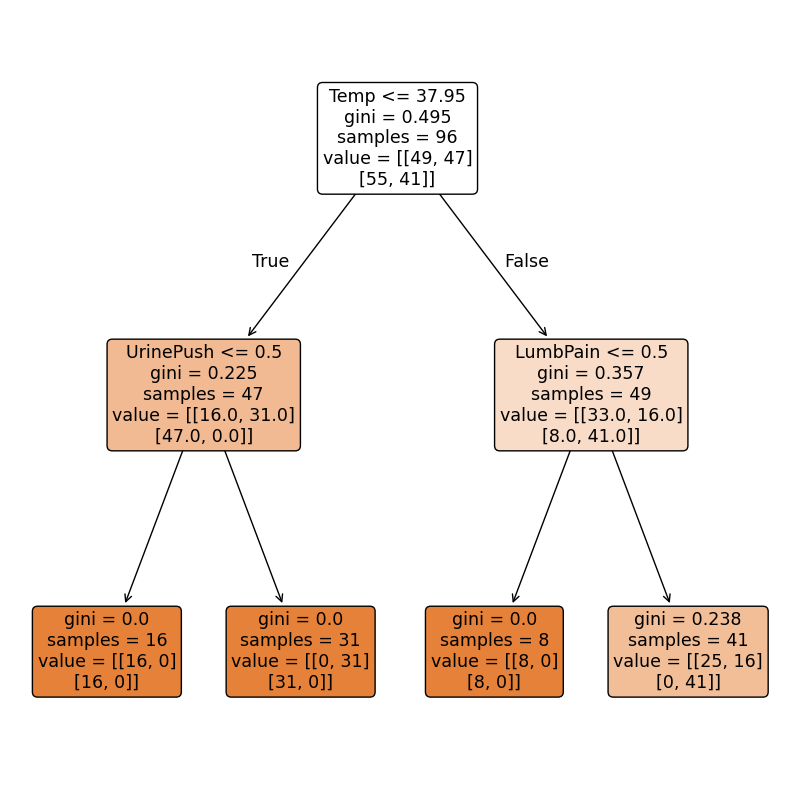

In [8]:
# above, alpha 0.0508130081300813 has good trade off: small depth, second best / high-ish test acc
picked_alpha = ccp_alphas[1]
alpha_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=picked_alpha)
alpha_tree.fit(d_X_train, d_Y_train)

plt.figure(figsize=(10, 10))
plot_tree(alpha_tree, feature_names=["Temp", "Nausea", "LumbPain", "UrinePush", "MictPains", "Burning"], filled=True, rounded=True)
plt.show()

In [9]:
tree_to_pseudo(alpha_tree, feature_names)

 if ( Temp <= 37.95000076293945 ) {
   if ( UrinePush <= 0.5 ) {
     return [[1. 0.]
 [1. 0.]]
   } else {
     return [[0. 1.]
 [1. 0.]]
   }
 } else {
   if ( LumbPain <= 0.5 ) {
     return [[1. 0.]
 [1. 0.]]
   } else {
     return [[0.6097561 0.3902439]
 [0.        1.       ]]
   }
 }


Return Meanings:
- [[Prob Inflam NO, Prob Inflam YES][Prob Neph NO, Prob Neph YES]]
- [[1. 0.][1. 0.]] -> 100% Not Inflam + 100% Not Neph -> NEITHER
- [[0. 1.][1. 0.]] -> 100% Inflam + 100% Not Neph -> Inflammation
- [[1. 0.][1. 0.]] -> NEITHER
- [[0.6097561 0.3902439][0. 1.]] -> Not Inflam + 100% Neph -> Nephritis
- - ^^^ 60% Not Inflam > 40% Inflam = NOT Inflam

Question 2.b
- (Use first 1495 rows as training, rest as test)
- The data set has missing values
- Use a data imputation technique to deal with the missing values in the data set
- The data description mentions some features are nonpredictive -> Ignore those features

In [10]:
# first 5 columns are NOT predictive 
c_df = pd.read_csv("../data/communities.data", header=None, na_values="?") # converts ? -> NaN
c_df = c_df.iloc[:, 5:] # ignore first 5 columns

mean_impute = SimpleImputer(strategy="mean")

# just doing mean imputation
c_df = pd.DataFrame(mean_impute.fit_transform(c_df))

c_df_train = c_df.iloc[:1495]
c_X_train = c_df_train.iloc[:, :-1]
c_Y_train = c_df_train.iloc[:, -1] # last column

c_df_test = c_df.iloc[1495:]
c_X_test = c_df_test.iloc[:, :-1]
c_Y_test = c_df_test.iloc[:, -1]

Question 2.c
- Plot a correlation matrix for the features in the data set

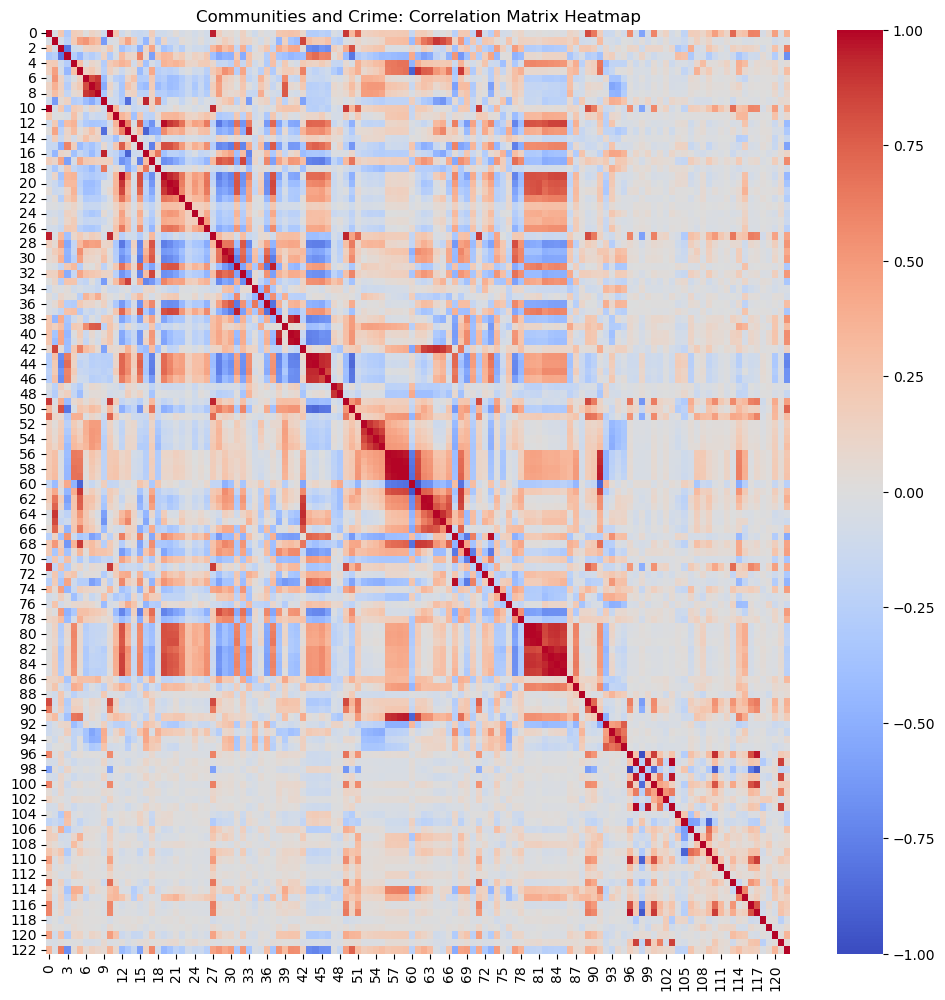

In [11]:
# using Seaborn heatmap
corr_matrix = c_df.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)

plt.title("Communities and Crime: Correlation Matrix Heatmap")
plt.show()

Question 2.d
- Calculate the Coefficient of Variation CV for each feature, where CV = s/m
- - s = sample standard deviation, m = sample mean

In [12]:
cdf_stddev = c_df.std()
cdf_mean = c_df.mean()
cdf_cv = cdf_stddev / cdf_mean

coeff_var_df = pd.DataFrame({"StdDev" : cdf_stddev, "Mean" : cdf_mean, "CV" : cdf_cv})